In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, os, sparse, sys, warnings, yaml, vcf, pickle, shutil, subprocess
import scipy.optimize

os.chdir("../")
who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)

sys.path.append("utils")
from data_utils import *
from analysis_utils import *
from inSilicoMut_utils import *
import seaborn as sns
import scipy.stats as st
plt.rcParams['figure.dpi'] = 150
import statsmodels.stats.api as sm
from statsmodels.stats import contingency_tables, proportion

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression

from Bio import SeqIO
warnings.filterwarnings("ignore")

data_dir = "/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/single_drugs"
results_dir = "/n/data1/hms/dbmi/farhat/Sanjana/CNN_results"

#cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/Sanjana/MIC_data/criticalConcentrations_updated.csv")
cc_df = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/MIC/critical_concentrations_all.csv")

drug_abbr_dict = {"Delamanid": "DLM",
                  "Bedaquiline": "BDQ",
                  "Clofazimine": "CFZ",
                  "Ethionamide": "ETO",
                  "Linezolid": "LZD",
                  "Moxifloxacin": "MXF",
                  "Capreomycin": "CAP",
                  "Amikacin": "AMK",
                  "Pretomanid": "PMD",
                  "Pyrazinamide": "PZA",
                  "Kanamycin": "KAN",
                  "Levofloxacin": "LFX",
                  "Streptomycin": "STM",
                  "Ethambutol": "EMB",
                  "Isoniazid": "INH",
                  "Rifampicin": "RIF"
                 }

abbr_drug_dict = {value: key for key, value in drug_abbr_dict.items()}

# def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

#     if regression:
#         model_type = 'Reg'
#     else:
#         model_type = 'CNN'
    
#     results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
#     results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

#     # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
#     return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

def differences_significant_two_models(df, model_1, model_2, variable, regression=False, direction='two-sided'):

    if regression:
        model_type = 'LinReg'
    else:
        model_type = 'CNN'
    
    results_1 = df.query("Model==@model_type & Addl_Data==@model_1")[variable].values
    results_2 = df.query("Model==@model_type & Addl_Data==@model_2")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]


def differences_significant_CNN_Reg(df, model, variable, direction='two-sided'):

    results_1 = df.query("Model=='CNN' & Addl_Data==@model")[variable].values
    results_2 = df.query("Model=='LinReg' & Addl_Data==@model")[variable].values

    # return st.mannwhitneyu(results_1, results_2, alternative=direction)[1]
    return st.ttest_ind(results_1, results_2, alternative=direction, equal_var=False)[1]

model_loci = pd.read_csv("./data_processing/data_utils/drug_loci.csv")
model_loci[['Start', 'End']] = model_loci[['Start', 'End']].astype(int)

cryptic_wgs_metadata = pd.read_csv("/n/data1/hms/dbmi/farhat/rollingDB/metadata/cryptic_WGS_metadata.csv")
df_cryptic = pd.read_csv("MIC_data/CRyPTIC_reuse_table_20231208.csv")
df_geno = pd.read_csv("./data_processing/samples_pass_geno_QC.csv")

cc_dict = {'RIF': 0.5, 'INH': 0.2, 'EMB': 5, 'PZA': 100, 'ETO': 5, 'MXF': 0.5, 'LFX': 1, 'BDQ': 0.25, 'LZD': 1, 'CFZ': 1, 'DLM': 0.016}
drugs_lst = ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'PZA', 'RIF']

isolate_variants = pd.read_csv(os.path.join(os.path.dirname(data_dir), "isolate_variants_WHO_catalog.csv"))

def compute_t_distribution_confidence_intervals(df, col):

    df_summary = pd.DataFrame(df.groupby(['Drug', 'Model', 'Addl_Data'])[col].agg(['mean', 'std', 'count'])).reset_index().rename(columns={'mean': col})
    
    df_summary[f'{col}_LB'] = df_summary[col] + st.t.ppf(0.025, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])
    df_summary[f'{col}_UB'] = df_summary[col] + st.t.ppf(0.975, df=df_summary['count']-1) * df_summary['std'] / np.sqrt(df_summary['count'])

    assert len(df_summary.query(f"{col} < {col}_LB")) == 0
    assert len(df_summary.query(f"{col} > {col}_UB")) == 0

    return df_summary

/tmp/ipykernel_9853/1574501394.py:8: DtypeWarning: Columns (36,37,99,100,102,103,106,108,112) have mixed types. Specify dtype option on import or set low_memory=False.
  who_variants = pd.read_csv("./data_processing/data_utils/WHO_catalog_V2.csv", header=[2]).reset_index(drop=True)


# Compute Essential Agreement on CRyPTIC Only to compare to https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012260

In [137]:
df_EA = pd.DataFrame(columns = ['Drug', 'CV', 'EA'])
i = 0

for drug in drugs_lst:

    if drug == 'PZA':
        model = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        model = f"{drug}_augment_lineage_amino_acid"
    else:
        model = f"{drug}_lineage_amino_acid"

    df_full = pd.read_csv(f"{data_dir}/{drug}/data_for_model.csv")
    cryptic_samples = df_full.query("DB_OF_ORIGIN=='CRyPTIC' & category=='test_set'").ROLLINGDB_ID.values

    print(model, len(cryptic_samples))

    if len(cryptic_samples) > 0:
        
        for cv in np.arange(len(glob.glob(f"{results_dir}/{model}/cross_validation/test_predictions_*.csv"))):
            df_pred = pd.read_csv(f"{results_dir}/{model}/cross_validation/test_predictions_{cv}.csv")
            _, _, within_doubling = boundedLoss_predict(df_pred.query("Isolate in @cryptic_samples"), y_pred_col="y_pred", lower_bounds_col="lower", upper_bounds_col="upper")
            df_EA.loc[i, :] = [drug, cv, within_doubling]
            i += 1
            
df_EA['Addl_Data'] = 'Final'
df_EA['Model'] = 'CNN'

BDQ_augment_lineage_amino_acid 1726
EMB_lineage_amino_acid 1515
ETO_lineage_amino_acid 1761
INH_lineage_amino_acid 1869
LFX_lineage_amino_acid 1549
MXF_lineage_amino_acid 1349
PZA_amino_acid 0
RIF_lineage_amino_acid 1720


In [140]:
df_EA_CIs = compute_t_distribution_confidence_intervals(df_EA, 'EA')

df_EA_cryptic = pd.DataFrame({'Drug': ['BDQ', 'EMB', 'ETO', 'INH', 'LFX', 'MXF', 'RIF'], 
                              'EA_cryptic': [0.933, 0.950, 0.913, 0.942, 0.949, 0.909, 0.929],
                              'EA_cryptic_LB': [0.923, 0.94, 0.901, 0.932, 0.940, 0.895, 0.919],
                              'EA_cryptic_UB': [0.944, 0.96, 0.924, 0.951, 0.959, 0.922, 0.94]
                             })

df_EA_cryptic = df_EA_cryptic.merge(df_EA_CIs, on='Drug')
df_EA_cryptic['diff'] = df_EA_cryptic['EA_cryptic'] - df_EA_cryptic['EA']
df_EA_cryptic.to_csv("EA_cryptic_data.csv", index=False)

In [143]:
df_EA_cryptic[['Drug', 'EA_cryptic_LB', 'EA_cryptic', 'EA_cryptic_UB', 'EA_LB', 'EA', 'EA_UB', 'diff']]

,Drug,EA_cryptic_LB,EA_cryptic,EA_cryptic_UB,EA_LB,EA,EA_UB,diff
0,BDQ,0.923,0.933,0.944,0.937285,0.939282,0.941278,-0.006282
1,EMB,0.940,0.950,0.960,0.931209,0.940198,0.949187,0.009802
2,ETO,0.901,0.913,0.924,0.896261,0.901079,0.905897,0.011921
3,INH,0.932,0.942,0.951,0.919592,0.921562,0.923533,0.020438
4,LFX,0.940,0.949,0.959,0.926896,0.927566,0.928237,0.021434
5,MXF,0.895,0.909,0.922,0.871101,0.879318,0.887535,0.029682
6,RIF,0.919,0.929,0.940,0.954418,0.956395,0.958372,-0.027395


In [145]:
# difference in percentage points
df_EA_cryptic['diff'].mean()*100

0.8514229310403449

# Quantitative Model Comparison

In [23]:
def get_all_single_drug_models(drug, regression=False):
    '''
    This function gets all the models for a given drug that have model results
    '''

    # gets all directories with the drug name
    CNN_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/results.csv"))
    
    # if regression or bootstrap, then all directories must also have those corresponding directories. The regression script performs bootstrapping, so don't need to check them separately
    if regression:
        regression_fNames = glob.glob(os.path.join(results_dir, f"{drug}*/ridge/results.csv"))
    else:
        regression_fNames = []
        
    df_combined = []
    
    for fName in CNN_fNames + regression_fNames:
        
        if 'old' not in fName:
        
            df = pd.read_csv(fName)

            model_name = '– Lineage'

            num_addl_features = 0

            if 'lineage' in fName:
                # model_name += '\n+Lineage'
                model_name = '+ Lineage'
                num_addl_features += 1

            if 'amino_acid' not in fName:
                model_name += '\n– AA Properties'
                num_addl_features += 1

            if 'tier2' in fName:
                model_name += '\n+ Tier 2 Loci'
                num_addl_features += 1

            if '_AF25' in fName:
                model_name += '\nAF = 25%'
                num_addl_features += 1
            # else:
            #     model_name += '\n AF = 75%'

            if 'augment' in fName:
                model_name += '\nBinary Augment'
                num_addl_features += 1

            # remove leading newline characters
            model_name = model_name.lstrip()

            df['Addl_Data'] = model_name
            df_combined.append(df)

    df_combined = pd.concat(df_combined)

    # check no duplicate row identifiers
    assert len(df_combined[['Model', 'Addl_Data', 'CV']].drop_duplicates()) == len(df_combined)
        
    # exponentiate errors
    for col in ['Binned_MAE', 'Binned_MSE']:
        df_combined[f'{col}_exp'] = np.exp2(df_combined[col])

    # add
    df_combined['Without_doubling'] = 1 - df_combined['Within_doubling']

    return df_combined

In [24]:
df_combined_all_drugs = pd.concat([get_all_single_drug_models(drug, regression=True) for drug in drugs_lst])

df_combined_all_drugs['Model'] = df_combined_all_drugs['Model'].replace('Reg', 'LinReg')

df_combined_all_drugs['Drug'] = df_combined_all_drugs['Drug'].map(abbr_drug_dict)

plotting_order = df_combined_all_drugs.sort_values(['Drug', 'Model', 'Addl_Data'], ascending=[True, False, False]).groupby(['Drug', 'Model', 'Addl_Data'], sort=False).Binned_MAE.mean().index.values

df_combined_all_drugs.to_csv("model_results_combined.csv", index=False)

# Plot for G4 Talk May 7, 2025

In [14]:
df_plot = pd.concat([df_combined_all_drugs.loc[(df_combined_all_drugs["Drug"]=='Pyrazinamide') & (df_combined_all_drugs["Addl_Data"] == '– Lineage')],
                     df_combined_all_drugs.loc[(df_combined_all_drugs["Drug"]=='Bedaquiline') & (df_combined_all_drugs["Addl_Data"] == '+ Lineage\nBinary Augment')],
                     df_combined_all_drugs.loc[(~df_combined_all_drugs["Drug"].isin(['Bedaquiline', 'Pyrazinamide'])) & (df_combined_all_drugs["Addl_Data"] == '+ Lineage')]
                    ])

# df_plot = df_combined_all_drugs.loc[df_combined_all_drugs["Addl_Data"] == '+ Lineage']

# should be 80: 5 samples x 2 models x 8 drugs
len(df_plot)

80

In [15]:
def single_metric_forest_plot(df, col_name, xlabel_name, models_lst, convert_to_percent=False, saveName=None):

    df_summary = df.copy()
    
    offset = 0.25
    y_pos = np.arange(df_summary.Drug.nunique())
    
    # colors = dict(zip(['CNN', 'LinReg', 'Catalog'], sns.color_palette("Set2", n_colors=3).as_hex()))
    colors = dict(zip(["CNN", "LinReg", "Catalog"], [sns.color_palette("Set2").as_hex()[0], sns.color_palette("Set2").as_hex()[1], sns.color_palette("Set2").as_hex()[1]]))

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 3.5))

    if convert_to_percent:
        df_summary[[col_name, f'{col_name}_LB', f'{col_name}_UB']] *= 100
    
    # Plot each model (CNN, regression, catalog), separately with a dodge
    for i, model in enumerate(models_lst):
        
        model_data = df_summary.query("Model==@model")
        
        ax.errorbar(
            model_data[col_name], 
            y_pos + (i - len(models_lst) / 2) * offset,  # Dodge the y-position
            xerr=[
                model_data[col_name] - model_data[f'{col_name}_LB'], 
                model_data[f'{col_name}_UB'] - model_data[col_name]
            ],
            fmt='o', 
            markersize=5,
            label=model,  # Use model name as the legend label
            elinewidth=1, 
            capsize=3,
            color=colors[model],
        )
    
    # Customize the plot
    # ax.set_xlim(right=1)
    
    if convert_to_percent:
        plt.xlim(right=100)
    else:
        plt.xlim(left=0, right=1)
        
    ax.set_yticks(y_pos)
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=9)
    ax.set_yticklabels(list(model_data.Drug.unique()), fontsize=9)
    ax.set_xlabel(xlabel_name)
    # ax.set_title("Specificity of Binary and Quantiative CNN Models")
    ax.invert_yaxis()  # Invert y-axis to have the first study at the top
    ax.legend(title="", loc="lower left", fontsize=9)
    
    # Show the plot
    sns.despine()
    plt.tight_layout()

    if saveName is not None:
        plt.savefig(saveName, format='svg')
    else:
        plt.show()

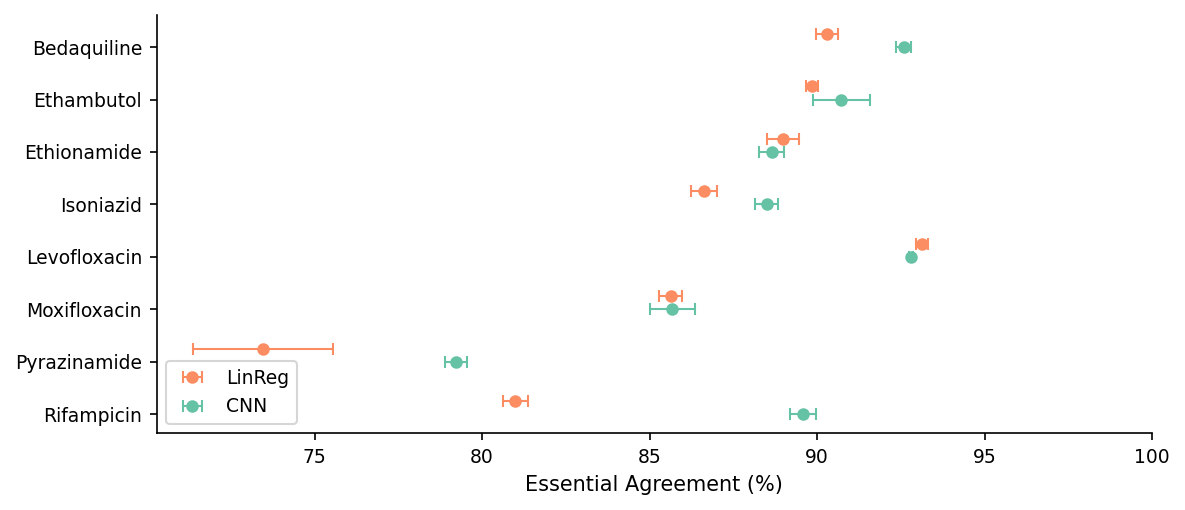

In [16]:
col = 'Within_doubling'
df_summary = compute_t_distribution_confidence_intervals(df_plot, col)

col_name = 'Within_doubling'
xlabel_name = 'Essential Agreement (%)'
models_lst = ['LinReg', 'CNN']
convert_to_percent = True

single_metric_forest_plot(df_summary, col_name, xlabel_name, models_lst, convert_to_percent=convert_to_percent, saveName=f"/home/sak0914/MtbQuantCNN/results/EA_comparison.svg")

In [23]:
# col = 'Binned_MAE'
# df_summary = compute_t_distribution_confidence_intervals(df_plot, col)

# col_name = 'Binned_MAE'
# xlabel_name = 'Mean Absolute Error (log2-MIC)'
# models_lst = ['LinReg', 'CNN']
# convert_to_percent = False

# single_metric_forest_plot(df_summary, col_name, xlabel_name, models_lst, convert_to_percent=convert_to_percent, saveName=f"/home/sak0914/MtbQuantCNN/results/MAE_comparison.svg")

In [7]:
def plot_single_drug_model_comparison(drug, df_combined, plot_col='Binned_MAE', model_order=None, mean_bar_offset=0.2, mean_bar_width=0.1, y_min=None, y_max=None, ylabel='', title='', saveName=None):

    # color_palette = dict(zip(["CNN", "LinReg", "Catalog"], sns.color_palette("Set2").as_hex()))

    color_palette = dict(zip(["CNN", "LinReg", "Catalog"], [sns.color_palette("Set2").as_hex()[0], sns.color_palette("Set2").as_hex()[1], sns.color_palette("Set2").as_hex()[1]]))

    if model_order is None:
        model_order = ['– Lineage', '+ Lineage'] #, '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci']

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")

    # df_combined['Model'] = df_combined['Model'].replace('LinReg', 'Regression')

    # convert to percentages
    if 'doubling' in plot_col:
        df_combined[plot_col] *= 100

    fig_width = 1.2 * df_combined.Addl_Data.nunique()
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, 3))
    
    sns.stripplot(data=df_combined,
                  x='Addl_Data',
                  order=model_order,
                  y=plot_col,
                  hue='Model',
                  hue_order=['LinReg', 'CNN'],
                  palette=color_palette,
                  dodge=True,
                  jitter=True,
                  edgecolor='black',
                  linewidth=0.75,
                  size=5,
                  alpha=0.8,
                  zorder=1,
                  ax=ax
                  #log_scale=2
                 )
    
    for i, model_name in enumerate(model_order):
        for k, model_type in enumerate(['LinReg', 'CNN']):
            
            median_error = df_combined.query(f"Model==@model_type & Addl_Data==@model_name")[plot_col].median()
    
            if k == 0:
                xpos = ax.get_xticks()[i] - mean_bar_offset
            else:
                xpos = ax.get_xticks()[i] + mean_bar_offset
                
            ax.hlines(y=median_error, xmin=xpos-mean_bar_width, xmax=xpos+mean_bar_width, color=color_palette[model_type], zorder=0)

    ref_font_size = 8
    
    plt.xlabel('', fontsize=ref_font_size)
    plt.ylabel(ylabel, fontsize=ref_font_size)
    plt.title(f'{abbr_drug_dict[drug]}', fontsize=ref_font_size)
    
    plt.xticks(fontsize=ref_font_size-1.5)
    plt.yticks(fontsize=ref_font_size-1)
    plt.legend(title='', fontsize=ref_font_size-1, loc='best', ncols=2)
    
    # try:
    #     ax.get_legend().remove()
    # except:
    #     pass

    if y_max is None:
        y_max = df_combined[plot_col].max()*1.05
    
    plt.ylim(bottom=y_min, top=y_max)
    sns.despine()
    plt.tight_layout()

    if saveName is None:
        plt.show()
    else:
    
        if not os.path.isdir(os.path.dirname(saveName)):
            os.mkdir(os.path.dirname(saveName))
        
        plt.savefig(saveName, format='svg', bbox_inches='tight')

In [8]:
def get_performance_comparison_CNN_Reg(drug, df_combined, model_order=None, plot_col='Binned_MAE', y_min=None, saveName=None):
    
    # df_combined = get_all_single_drug_models(drug, regression=True)
    
    if model_order is None:
        # model_order = ['- Lineage', '+ Lineage', '- Lineage\n+ Tier 2 Loci', '+ Lineage\n+ Tier 2 Loci'] #['+AA Properties', '+Lineage\n+AA Properties']
        model_order = df_combined.Addl_Data.unique()

    # keep only the models specified
    df_combined = df_combined.query("Addl_Data in @model_order")
    
    if 'exp' in plot_col.lower():
        # plot_y_min = 1
        title = 'Mean Absolute Error (Doublings)'
        ylabel = 'Relative Error'
        save_name = 'MAE_exp'
    elif 'doubling' in plot_col.lower():
        # plot_y_min = 0
        title = 'Essential Disagreement'
        ylabel = 'Essential Disagreement'
        save_name = 'EA'
    elif plot_col in ['Spearman', 'Pearson']:
        ylabel = plot_col
        title = plot_col
        # plot_y_min = 0.5
        save_name = plot_col
    else:
        # plot_y_min = 0
        title = 'Mean Absolute Error'
        ylabel = 'Mean Absolute Error (log2-MIC)'
        save_name = 'MAE'

    if '- Lineage\n+ Tier 2 Loci' in model_order:
        save_name += "_tier2"

    # # override
    # if y_min is not None:
    #     plot_y_min = y_min

    plot_single_drug_model_comparison(drug, df_combined, plot_col=plot_col, model_order=model_order, mean_bar_width=0.15, y_min=y_min, ylabel=ylabel, title=title, saveName=saveName)        
            
    df_pvals = pd.DataFrame(columns=['Model', 'Variable', 'CNN_better_pval', 'Reg_better_pval', 'Two_sided_pval'])
    i = 0

    for model in df_combined.Addl_Data.unique():
        
        df_pvals.loc[i, :] = [model.replace('\n', ','), 
                              plot_col, 
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='less'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='greater'),
                              differences_significant_CNN_Reg(df_combined, model, plot_col, direction='two-sided')
                             ]
        i += 1
        
        if plot_col != 'Without_doubling':
            df_pvals.loc[i, :] = [model.replace('\n', ','), 
                                  'Without_doubling',
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='less'),
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='greater'),
                                  differences_significant_CNN_Reg(df_combined, model, 'Without_doubling', direction='two-sided')
                                 ]
            i += 1

    # # perform FDR correction at the single-drug level
    # _, cnn_better_bh_pvals, _, _ = sm.multipletests(df_pvals['CNN_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_CNN_better_pval'] = cnn_better_bh_pvals
    
    # _, reg_better_bh_pvals, _, _ = sm.multipletests(df_pvals['Reg_better_pval'], method='fdr_bh', is_sorted=False, returnsorted=False)
    # df_pvals['BH_Reg_better_pval'] = reg_better_bh_pvals
    
    df_pvals['Drug'] = drug
    
    return df_pvals

# 0. Compare +/- Augmentation for Bedaquiline

BDQ


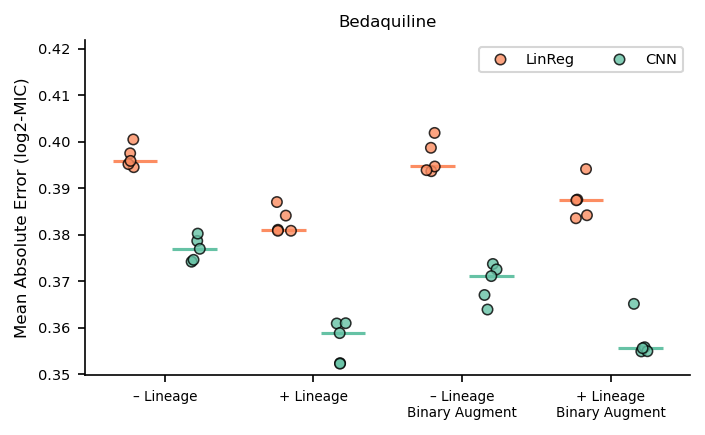

In [17]:
for drug in os.listdir(data_dir):

    if drug in ['BDQ']:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        model_order = ['– Lineage', '+ Lineage', '– Lineage\nBinary Augment', '+ Lineage\nBinary Augment']
        
        _ = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = model_order,
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE_augment_compare.svg"
                                                     )

In [18]:
# does binary augmentation significantly improve without lineage
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '– Lineage\nBinary Augment', '– Lineage', 'Binned_MAE', regression=False, direction='less')

0.006319066577618547

In [19]:
# does binary augmentation significantly improve with lineage
differences_significant_two_models(df_combined_all_drugs.query("Drug=='Bedaquiline'"), '+ Lineage\nBinary Augment', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

0.5276637505602293

In [22]:
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\nBinary Augment'].query("Drug=='Pyrazinamide' & Model=='CNN'").Binned_MAE,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=0.364017422980435, pvalue=0.6370094650566578, df=7.4326209052525085)

In [25]:
# for BDQ, remove the unaugmented cases
df_combined_all_drugs = df_combined_all_drugs.loc[~((df_combined_all_drugs['Drug']=='Bedaquiline') & (~df_combined_all_drugs['Addl_Data'].str.contains('Augment')))]

df_combined_all_drugs['Addl_Data'] = df_combined_all_drugs['Addl_Data'].str.replace('\nBinary Augment', '')

# 1. Does lineage improve MAE?

In [27]:
for drug in drugs_lst:
    
    full_drug_name = abbr_drug_dict[drug]
        
    lineage_better_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='greater')
    lineage_worse_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='less')

    with_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '+ Lineage' & Model=='CNN'").Binned_MAE.mean()
    no_lineage_MAE = df_combined_all_drugs.query("Drug==@full_drug_name & Addl_Data == '– Lineage' & Model=='CNN'").Binned_MAE.mean()

    if lineage_better_pval <= 0.05:
        print(f"{full_drug_name}: + Lineage better, pval = {lineage_better_pval}, Δ = {with_lineage_MAE - no_lineage_MAE}")
    elif lineage_worse_pval <= 0.05:
        print(f"{full_drug_name}: + Lineage worse, pval = {lineage_worse_pval} Δ = {with_lineage_MAE - no_lineage_MAE}")
    else:
        # two_sided_pval = differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"), '– Lineage', '+ Lineage', 'Binned_MAE', regression=False, direction='two-sided')

        print(f"{full_drug_name}: No difference, pval = {lineage_better_pval}")

Bedaquiline: + Lineage better, pval = 0.0008807018106231542, Δ = -0.012386062625521443
Ethambutol: + Lineage better, pval = 0.03560671906860689, Δ = -0.003902499979236307
Ethionamide: + Lineage better, pval = 0.0014894351577719482, Δ = -0.026060629118770884
Isoniazid: No difference, pval = 0.23240999449358896
Levofloxacin: + Lineage better, pval = 0.0010001735887700037, Δ = -0.00615761516394861
Moxifloxacin: + Lineage better, pval = 1.4986398413119178e-09, Δ = -0.08998945603241615
Pyrazinamide: + Lineage worse, pval = 0.018434829160430533 Δ = 0.07441862412642752
Rifampicin: No difference, pval = 0.9102903404393828


In [ ]:
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.05, 'Asterisk'] = '*'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.01, 'Asterisk'] = '**'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.001, 'Asterisk'] = '***'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.0001, 'Asterisk'] = '****'

In [13]:
st.ttest_ind(df_combined_all_drugs.query("Drug=='Ethambutol' & Model=='CNN' & Addl_Data in ['– Lineage']").Binned_MAE,
             df_combined_all_drugs.query("Drug=='Ethambutol' & Model=='CNN' & Addl_Data in ['+ Lineage']").Binned_MAE,
             equal_var=False,
             alternative='greater'
            )

TtestResult(statistic=2.121775725335579, pvalue=0.03560671906860689, df=7.057600397381599)

In [15]:
st.ttest_ind(df_combined_all_drugs.query("Drug=='Pyrazinamide' & Model=='CNN' & Addl_Data in ['– Lineage']").Binned_MAE,
             df_combined_all_drugs.query("Drug=='Pyrazinamide' & Model=='CNN' & Addl_Data in ['+ Lineage']").Binned_MAE,
             equal_var=False,
             alternative='less'
            )

TtestResult(statistic=-2.5965019161941303, pvalue=0.018434829160430533, df=6.726651877158774)

BDQ
EMB
ETO
INH
LFX
MXF
PZA
RIF


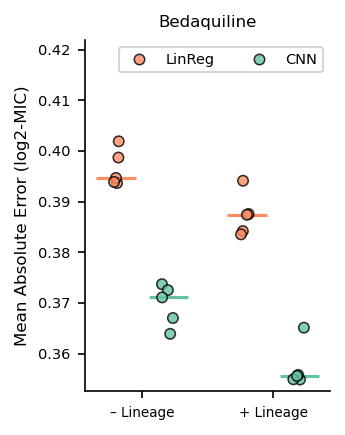

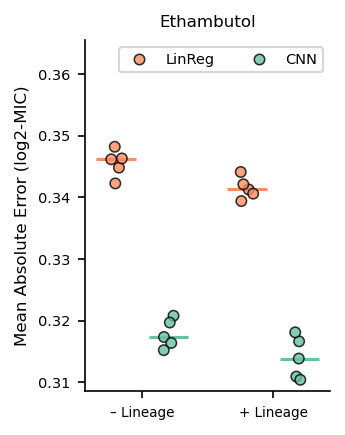

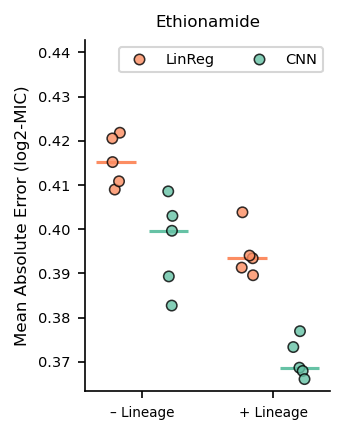

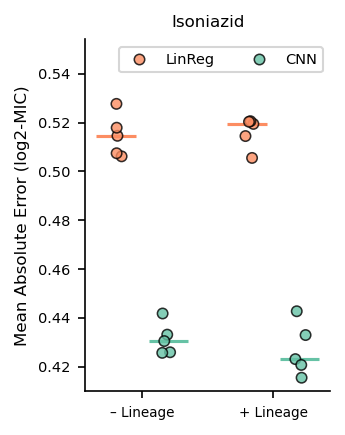

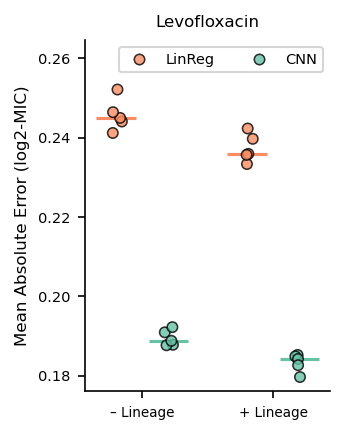

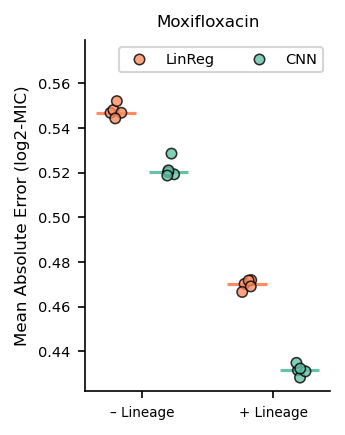

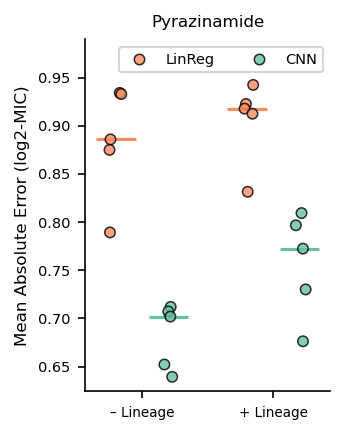

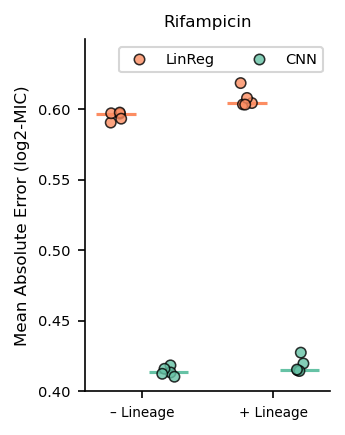

In [18]:
df_pvals_combined = []

for drug in os.listdir(data_dir):

    if drug in drugs_lst:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        df_pvals = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = ['– Lineage', '+ Lineage'],
                                                      plot_col='Binned_MAE', 
                                                      saveName=f"results/{full_drug_name}/MAE.svg"
                                                     )
        df_pvals_combined.append(df_pvals)

df_pvals_combined = pd.concat(df_pvals_combined)

BDQ
EMB
ETO
INH
LFX
MXF
PZA
RIF


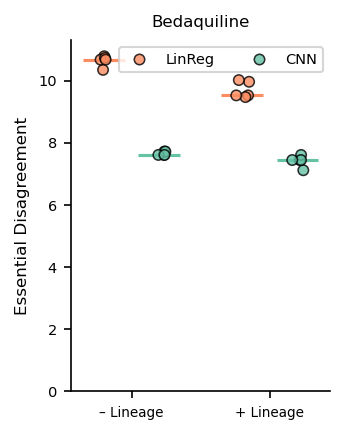

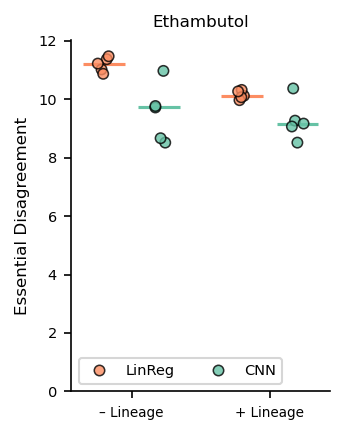

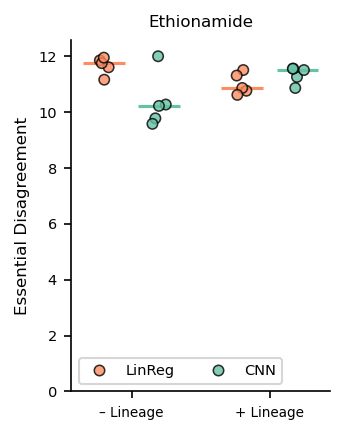

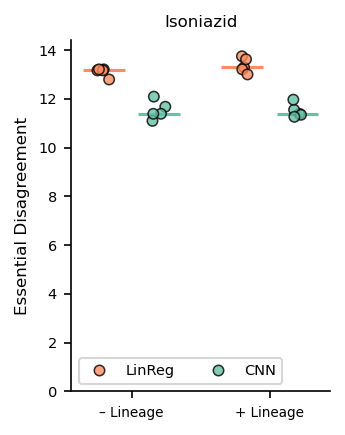

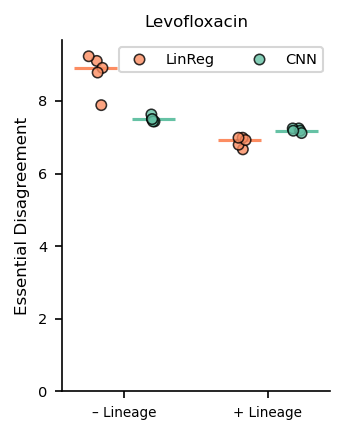

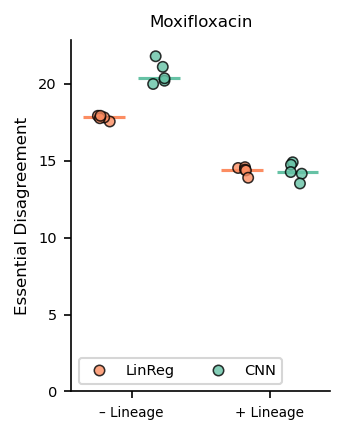

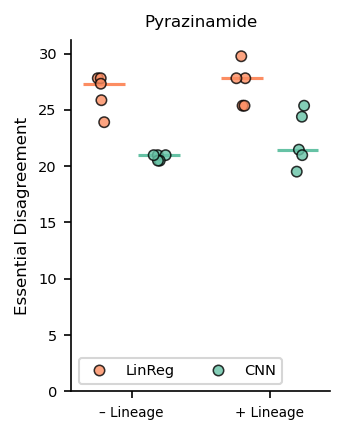

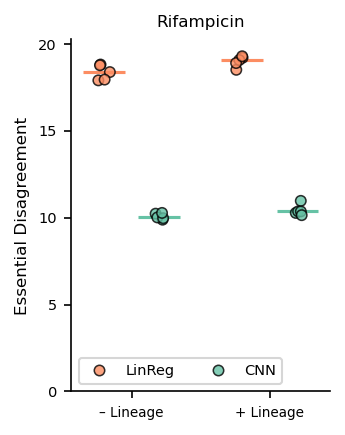

In [103]:
for drug in os.listdir(data_dir):

    if drug in drugs_lst:

        print(drug)
        full_drug_name = abbr_drug_dict[drug]
        
        _ = get_performance_comparison_CNN_Reg(drug, 
                                                      df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                      model_order = ['– Lineage', '+ Lineage'],
                                                      plot_col='Without_doubling', 
                                                      saveName=f"results/{full_drug_name}/EA.svg",
                                                       y_min=0
                                                     )

In [19]:
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.05, 'Asterisk'] = '*'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.01, 'Asterisk'] = '**'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.001, 'Asterisk'] = '***'
df_pvals_combined.loc[df_pvals_combined['CNN_better_pval'] <= 0.0001, 'Asterisk'] = '****'

In [47]:
len(df_pvals_combined.query("Variable=='Without_doubling'")), len(df_pvals_combined.query("Variable=='Without_doubling'").query("CNN_better_pval <= 0.05"))

(16, 12)

In [20]:
len(df_pvals_combined.query("Variable=='Binned_MAE'")), len(df_pvals_combined.query("Variable=='Binned_MAE'").query("CNN_better_pval <= 0.05"))

(16, 16)

In [106]:
df_pvals_combined.query("Variable=='Without_doubling' & ((Model == '– Lineage' & Drug == 'PZA') | (Model == '+ Lineage' & Drug != 'PZA'))").sort_values("CNN_better_pval").sort_values("Drug")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.0,1.0,0.000001,BDQ,****
3,+ Lineage,Without_doubling,0.021668,0.978332,0.043337,EMB,*
3,+ Lineage,Without_doubling,0.920561,0.079439,0.158878,ETO,n
3,+ Lineage,Without_doubling,0.000004,0.999996,0.000008,INH,****
3,+ Lineage,Without_doubling,0.997782,0.002218,0.004436,LFX,n
3,+ Lineage,Without_doubling,0.440659,0.559341,0.881317,MXF,n
1,– Lineage,Without_doubling,0.000663,0.999337,0.001325,PZA,***
3,+ Lineage,Without_doubling,0.0,1.0,0.0,RIF,****


In [100]:
df_pvals_combined.query("Variable=='Binned_MAE' & ((Model == '– Lineage' & Drug == 'PZA') | (Model == '+ Lineage' & Drug != 'PZA'))").sort_values("CNN_better_pval")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,RIF,****
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,MXF,****
2,+ Lineage,Binned_MAE,0.0,1.0,0.0,LFX,****
2,+ Lineage,Binned_MAE,0.000001,0.999999,0.000002,INH,****
2,+ Lineage,Binned_MAE,0.000002,0.999998,0.000004,EMB,****
2,+ Lineage,Binned_MAE,0.000002,0.999998,0.000004,BDQ,****
2,+ Lineage,Binned_MAE,0.000043,0.999957,0.000087,ETO,****
0,– Lineage,Binned_MAE,0.000226,0.999774,0.000452,PZA,***


In [37]:
df_pvals_combined.query("Variable=='Without_doubling' & ((Model == '– Lineage' & Drug == 'PZA') | (Model == '+ Lineage' & Drug != 'PZA'))").sort_values("CNN_better_pval")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.0,1.0,0.0,RIF,****
3,+ Lineage,Without_doubling,0.0,1.0,0.000001,BDQ,****
3,+ Lineage,Without_doubling,0.000004,0.999996,0.000008,INH,****
1,– Lineage,Without_doubling,0.000663,0.999337,0.001325,PZA,***
3,+ Lineage,Without_doubling,0.021668,0.978332,0.043337,EMB,*
3,+ Lineage,Without_doubling,0.440659,0.559341,0.881317,MXF,n
3,+ Lineage,Without_doubling,0.920561,0.079439,0.158878,ETO,n
3,+ Lineage,Without_doubling,0.997782,0.002218,0.004436,LFX,n


In [21]:
df_pvals_combined.query("Variable=='Binned_MAE'").query("Reg_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk


In [22]:
df_pvals_combined.query("Variable=='Without_doubling'").query("Reg_better_pval <= 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.997782,0.002218,0.004436,LFX,n
1,– Lineage,Without_doubling,0.999636,0.000364,0.000729,MXF,n


In [26]:
df_pvals_combined.query("Variable=='Without_doubling'").query("CNN_better_pval > 0.05 & Reg_better_pval > 0.05")

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug,Asterisk
3,+ Lineage,Without_doubling,0.920561,0.079439,0.158878,ETO,n
3,+ Lineage,Without_doubling,0.440659,0.559341,0.881317,MXF,n


In [36]:
for variable in ['Binned_MAE', 'Within_doubling']:

    min_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().min()
    max_val = df_combined_all_drugs.query("Addl_Data in ['– Lineage', '+ Lineage'] & Model=='CNN'").groupby('Drug')[variable].mean().max()

    print(variable, min_val, max_val)

Binned_MAE 0.1864126013894316 0.7198256541288333
Within_doubling 0.784390243902439 0.9265384615384615


# 2. Pyrazinamide comparison, +/- AA Properties

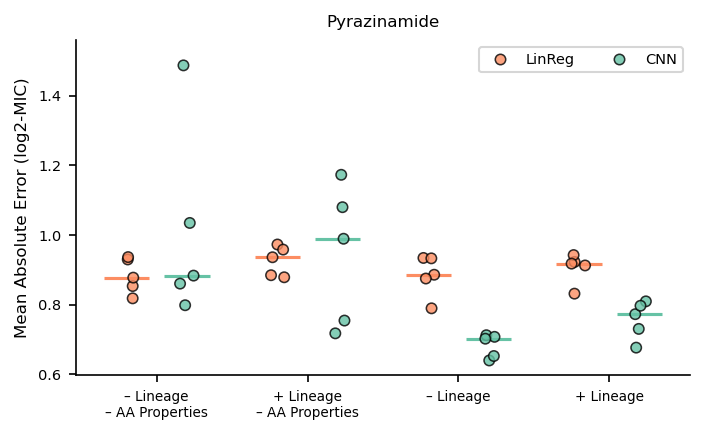

In [111]:
drug = 'PZA'
full_drug_name = abbr_drug_dict[drug]


model_order = ['– Lineage\n– AA Properties',
               '+ Lineage\n– AA Properties',
                '– Lineage', 
               '+ Lineage',
              ]

df_pvals_PZA = get_performance_comparison_CNN_Reg(drug, 
                                                  df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                  model_order=model_order, 
                                                  plot_col='Binned_MAE', 
                                                  # y_min=0, 
                                                  saveName=f"results/{full_drug_name}/MAE_AA_property_compare.svg"
                                                 )

In [39]:
df_pvals_PZA

,Model,Variable,CNN_better_pval,Reg_better_pval,Two_sided_pval,Drug
0,"– Lineage,– AA Properties",Binned_MAE,0.819519,0.180481,0.360963,PZA
1,"– Lineage,– AA Properties",Without_doubling,0.641038,0.358962,0.717923,PZA
2,– Lineage,Binned_MAE,0.000226,0.999774,0.000452,PZA
3,– Lineage,Without_doubling,0.000663,0.999337,0.001325,PZA
4,"+ Lineage,– AA Properties",Binned_MAE,0.56856,0.43144,0.862879,PZA
5,"+ Lineage,– AA Properties",Without_doubling,0.10003,0.89997,0.20006,PZA
6,+ Lineage,Binned_MAE,0.000787,0.999213,0.001575,PZA
7,+ Lineage,Without_doubling,0.004247,0.995753,0.008494,PZA


In [54]:
full_drug_name = 'Pyrazinamide'

differences_significant_two_models(df_combined_all_drugs.query("Drug==@full_drug_name"),
                                   '– Lineage',
                                   '– Lineage\n– AA Properties',
                                   'Binned_MAE',
                                   regression=False,
                                   direction='less'
                                  )

0.028403839828585912

In [58]:
full_drug_name = 'Pyrazinamide'

df_combined_all_drugs.query("Drug==@full_drug_name & Model=='CNN' & Addl_Data=='– Lineage'").Binned_MAE.mean() - df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n– AA Properties'].query("Drug==@full_drug_name & Model=='CNN'").Binned_MAE.mean()

-0.33027235934112986

# 3. Ethionamide Tier 2 Comparison

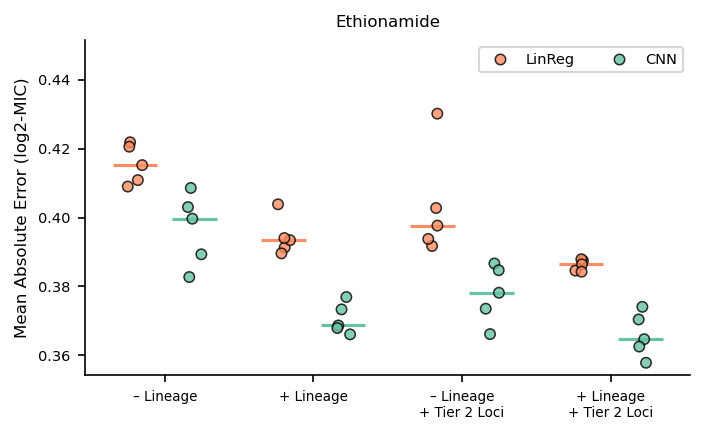

In [110]:
drug = 'ETO'
full_drug_name = abbr_drug_dict[drug]


model_order = ['– Lineage',
               '+ Lineage',
                '– Lineage\n+ Tier 2 Loci', 
               '+ Lineage\n+ Tier 2 Loci',
              ]

df_pvals_ETO = get_performance_comparison_CNN_Reg(drug, 
                                                  df_combined_all_drugs.query("Drug==@full_drug_name"), 
                                                  model_order=model_order, 
                                                  plot_col='Binned_MAE', 
                                                  # y_min=0, 
                                                  saveName=f"results/{full_drug_name}/MAE_tier2.svg"
                                                 )

In [121]:
# Tier 2 loci don't significantly improve predictions
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage\n+ Tier 2 Loci'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
            df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='+ Lineage'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
             equal_var=False,
            alternative='less'
            )

TtestResult(statistic=-1.3389199376010348, pvalue=0.110898892636907, df=7.113916042175423)

In [122]:
# Tier 2 loci improves predictions over no lineage model
st.ttest_ind(df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage\n+ Tier 2 Loci'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
            df_combined_all_drugs.loc[df_combined_all_drugs['Addl_Data']=='– Lineage'].query("Model=='CNN' & Drug=='Ethionamide'").Binned_MAE,
             equal_var=False,
            alternative='less'
            )

TtestResult(statistic=-3.1372315382066667, pvalue=0.007367254067246325, df=7.623737788738512)

# Binary Metrics comparison to WHO-based Predictions

In [100]:
# df_binary = pd.read_excel("analysis/binary_CNN_paper_Supp1.xlsx", sheet_name=None)

# if len(df_binary.keys()) == 1:
#     df_binary = df_binary[list(df_binary.keys())[0]]

In [101]:
# binary_results_drugs_lst = ['RIFAMPICIN', 'ISONIAZID', 'LEVOFLOXACIN', 'MOXIFLOXACIN', 'ETHAMBUTOL', 'ETHIONAMIDE', 'PYRAZINAMIDE']

# df_binary_cnn_summary = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].mean().reset_index()
# df_binary_cnn_summary_std = df_binary.query("Drug in @binary_results_drugs_lst & model=='SD-CNN'").groupby('Drug')[['sens', 'spec']].std().reset_index()

# df_quant_cnn_summary = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].mean().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})
# df_quant_cnn_summary_std = df_combined_all_drugs.query("Addl_Data=='+ Lineage' & Model=='CNN'").groupby('Drug')[['Sensitivity', 'Specificity']].std().reset_index().rename(columns={'Sensitivity': 'sens', 'Specificity': 'spec'})

In [59]:
WHO_catalog_sample_counts = pd.read_csv("~/who-analysis/data/samples_summary.csv")

In [74]:
def compute_exact_confidence_intervals(res_df, alpha):
    
    res_df = res_df.reset_index(drop=True)

    # add exact binomial confidence intervals for the binomial variables. The other two will be done in another function
    for i, row in res_df.iterrows():
        
        # will be null for the principal components, so skip them
        if not pd.isnull(row["TP"]):

                        # binomtest requires the numbers to be integers
            row[["TP", "FP", "TN", "FN"]] = row[["TP", "FP", "TN", "FN"]].astype(int)
            
            # Sensitivity: TP / (TP + FN)
            ci = st.binomtest(k=row["TP"], n=row["TP"] + row["FN"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Sens_LB", "Sens_UB"]] = [ci.low, ci.high]
            
            # Specificity: TN / (TN + FP)
            ci = st.binomtest(k=row["TN"], n=row["TN"] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["Spec_LB", "Spec_UB"]] = [ci.low, ci.high]

            # F1 score: 2TP / (2TP + FN + FP)
            ci = st.binomtest(k=2*row["TP"], n=2*row["TP"] + row['FN'] + row["FP"], p=0.5).proportion_ci(confidence_level=1-alpha, method='exact')
            res_df.loc[i, ["F1_LB", "F1_UB"]] = [ci.low, ci.high]
    
    return res_df

In [75]:
def read_in_process_binary_predictions(model_path, cc):

    df = pd.read_csv(f"{results_dir}/{model_path}/test_predictions.csv").query("Span_CC==0")

    # have to change names so that we can use the y_pred and y_test column names
    df.rename(columns={'y_test': 'y_test_log2', 'y_pred': 'y_pred_log2'}, inplace=True)

    cc = np.log2(cc)

    df.loc[df['y_test_log2'] > cc, 'y_test'] = 1
    df.loc[df['y_test_log2'] <= cc, 'y_test'] = 0
    
    df.loc[df['y_pred_log2'] > cc, 'y_pred'] = 1
    df.loc[df['y_pred_log2'] <= cc, 'y_pred'] = 0

    return df


def compute_confusion_matrix_values(df):

    df.loc[(df['y_pred']==1) & (df['y_test']==0), 'Group'] = 'FP'
    df.loc[(df['y_pred']==1) & (df['y_test']==1), 'Group'] = 'TP'
    df.loc[(df['y_pred']==0) & (df['y_test']==0), 'Group'] = 'TN'
    df.loc[(df['y_pred']==0) & (df['y_test']==1), 'Group'] = 'FN'

    return pd.DataFrame(df.Group.value_counts()).T

In [76]:
df_binary_statistics_CNN_catalog = []

for drug in drugs_lst:

    if drug in ['PZA']:
        model_path = f"{drug}_amino_acid"
    elif drug == 'BDQ':
        model_path = f"{drug}_augment_lineage_amino_acid"
    else:
        model_path = f"{drug}_lineage_amino_acid"

    cc = cc_dict[drug]

    df_CNN = read_in_process_binary_predictions(model_path, cc)

    # add sensitivity and specificity 95% confidence intervals
    df_CNN = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_CNN), 0.05)
    df_CNN['Drug'] = abbr_drug_dict[drug]
    df_CNN['Model'] = 'CNN'

    df_catalog = pd.read_csv(f"{results_dir}/{drug}/catalog_test_predictions_V2.csv")

    # add sensitivity and specificity 95% confidence intervals
    df_catalog = compute_exact_confidence_intervals(compute_confusion_matrix_values(df_catalog), 0.05)
    df_catalog['Drug'] = abbr_drug_dict[drug]
    df_catalog['Model'] = 'Catalog'

    df_binary_statistics_CNN_catalog.append(df_CNN)
    df_binary_statistics_CNN_catalog.append(df_catalog)

df_binary_statistics_CNN_catalog = pd.concat(df_binary_statistics_CNN_catalog)

# add the overall stats
df_binary_statistics_CNN_catalog['Sens'] = df_binary_statistics_CNN_catalog['TP'] / (df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FN'])
df_binary_statistics_CNN_catalog['Spec'] = df_binary_statistics_CNN_catalog['TN'] / (df_binary_statistics_CNN_catalog['TN'] + df_binary_statistics_CNN_catalog['FP'])

df_binary_statistics_CNN_catalog['F1'] = 2 * df_binary_statistics_CNN_catalog['TP'] / (2 * df_binary_statistics_CNN_catalog['TP'] + df_binary_statistics_CNN_catalog['FP'] + df_binary_statistics_CNN_catalog['FN'])

In [77]:
WHO_catalog_sample_counts.query("Drug in @df_binary_statistics_CNN_catalog.Drug").sort_values('Genos')

,Drug,Genos,SNP_Matrix,ALL_Phenos,WHO_Phenos,ALL_Only,MIC,ALL_MIC,Tier1_LOF,Tier1_Inframe,Tier2_LOF,Tier2_Inframe
1,Bedaquiline,14135,14135,14135,2165,11970,12659,11231,801,18,72.0,127.0
6,Ethionamide,20936,20936,20936,5999,14937,12688,9585,2273,145,670.0,30.0
13,Pyrazinamide,21319,21319,21319,19889,1430,1146,0,637,70,5436.0,88.0
11,Moxifloxacin,22783,22783,22783,8439,14344,12749,10059,0,13,623.0,38.0
9,Levofloxacin,27576,27576,27576,12441,15135,11445,8934,1,24,700.0,49.0
5,Ethambutol,45515,45515,45515,33240,12275,12914,9721,1,49,1202.0,106.0
14,Rifampicin,47730,47730,47730,35401,12329,12874,7115,0,180,1123.0,115.0
7,Isoniazid,48706,48706,48706,34881,13825,12825,7018,291,36,15431.0,102.0


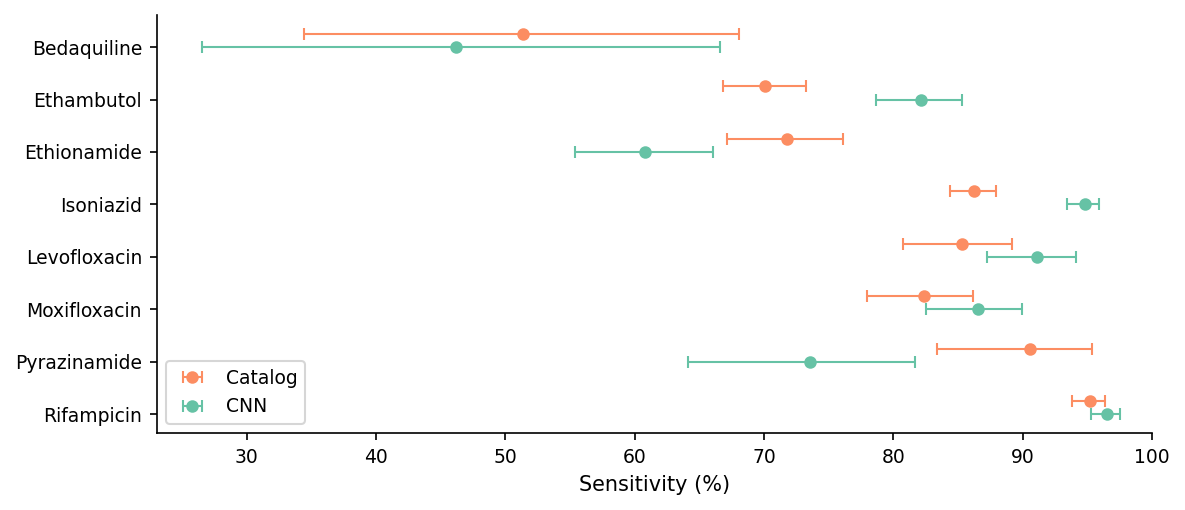

In [78]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Sens', 'Sensitivity (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Sensitivity_comparison.svg")


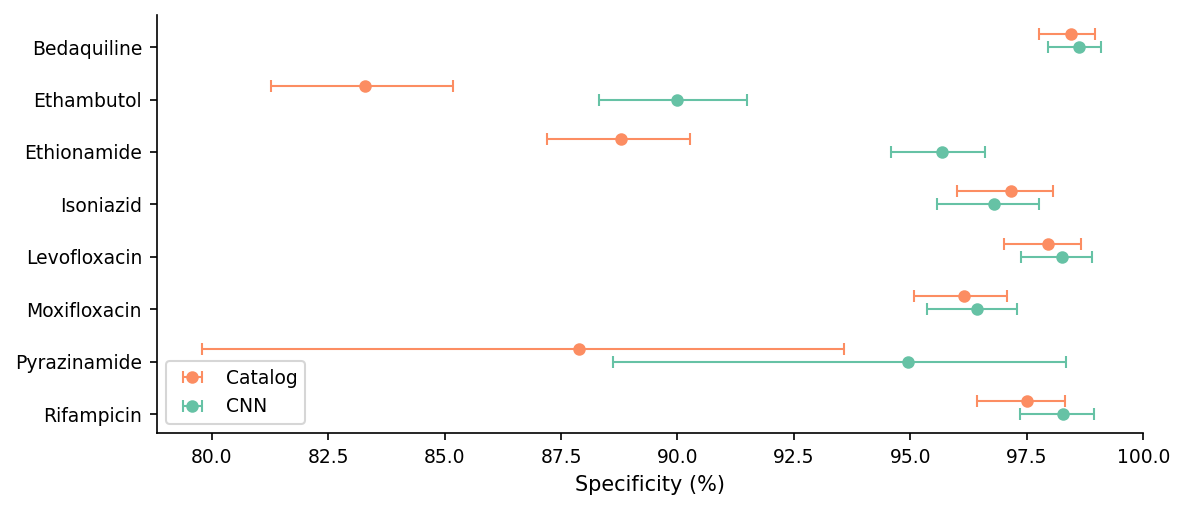

In [79]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'Spec', 'Specificity (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/Specificity_comparison.svg")


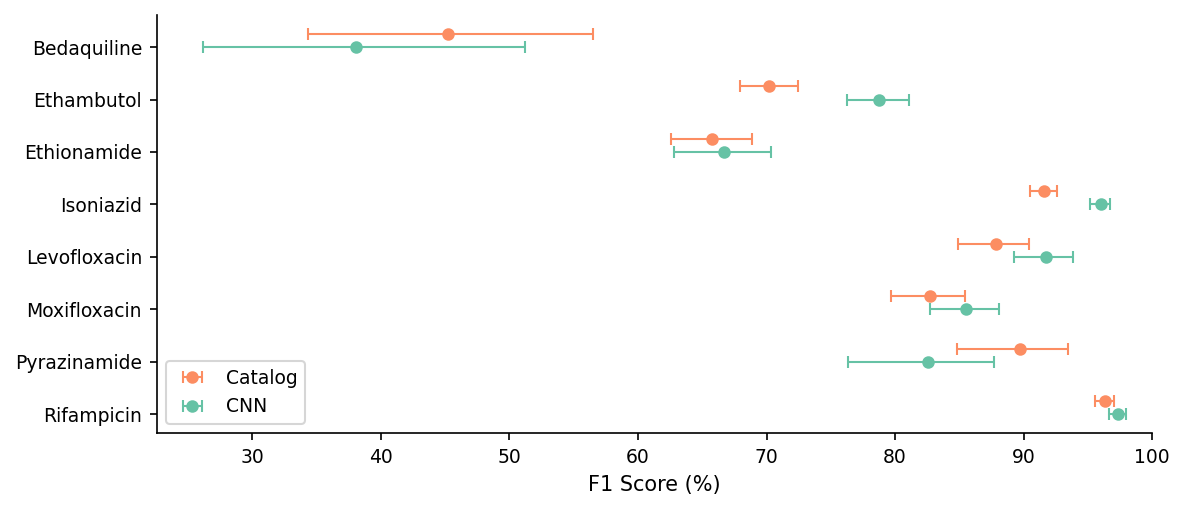

In [80]:
single_metric_forest_plot(df_binary_statistics_CNN_catalog, 'F1', 'F1 Score (%)', ['Catalog', 'CNN'], convert_to_percent=True, saveName=f"/home/sak0914/MtbQuantCNN/results/F1_comparison.svg")

In [81]:
# df_F1_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='F1')
# df_F1_comparison['Diff'] = df_F1_comparison['CNN'] - df_F1_comparison['Catalog']

df_Sens_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Sens')
df_Sens_comparison['Diff'] = df_Sens_comparison['CNN'] - df_Sens_comparison['Catalog']

df_Spec_comparison = df_binary_statistics_CNN_catalog.pivot(index='Drug', columns='Model', values='Spec')
df_Spec_comparison['Diff'] = df_Spec_comparison['CNN'] - df_Spec_comparison['Catalog']

In [86]:
df_Sens_comparison.Diff.min()*100, df_Sens_comparison.Diff.mean()*100, df_Sens_comparison.Diff.max()*100

(-16.981132075471706, -0.14259199935394845, 12.063892391761243)

In [87]:
df_Spec_comparison.Diff.min()*100, df_Spec_comparison.Diff.mean()*100, df_Spec_comparison.Diff.max()*100

(-0.36663611365719273, 2.724549228703742, 7.070707070707072)

In [88]:
df_binary_statistics_CNN_catalog.set_index(['Drug', 'Model']).to_csv("./supplement/binary_classification_metrics.csv")

In [89]:
df_Sens_comparison

Model,CNN,Catalog,Diff
Drug,,,
Bedaquiline,0.461538,0.513514,-0.051975
Ethambutol,0.821494,0.700855,0.120639
Ethionamide,0.608309,0.717445,-0.109136
Isoniazid,0.947846,0.862046,0.085800
Levofloxacin,0.911263,0.853242,0.058020
Moxifloxacin,0.865330,0.823362,0.041968
Pyrazinamide,0.735849,0.905660,-0.169811
Rifampicin,0.965035,0.951947,0.013088


## Are the sensitivity and specificity differences significant

In [94]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                             alternative='smaller'
                                            )
    
    if pval <= 0.05:
        print(f"{drug} CNN sensitivity less: {pval}")
    else:
        
        _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TP'].values, 
                                                 nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TP', 'FN']].values.sum(axis=1),
                                                 alternative='larger'
                                                )
        
        if pval <= 0.05:
            print(f"{drug} CNN sensitivity greater: {pval}")
    
    # print(drug, pval)

Ethambutol CNN sensitivity greater: 2.255449702912691e-07
Ethionamide CNN sensitivity less: 0.0008259265079300101
Isoniazid CNN sensitivity greater: 1.0011849915578915e-14
Levofloxacin CNN sensitivity greater: 0.014671298538692484
Pyrazinamide CNN sensitivity less: 0.0006340525435584146


In [96]:
# CNN first, then catalog
for drug in df_binary_statistics_CNN_catalog.Drug.unique():
    
    _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                             nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                             alternative='larger'
                                            )
    
    if pval <= 0.05:
        print(f"{drug} CNN specificity greater: {pval}")
    else:
        
        _, pval = proportion.proportions_ztest(count=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')['TN'].values, 
                                                 nobs=df_binary_statistics_CNN_catalog.query("Drug==@drug").sort_values('Model')[['TN', 'FP']].values.sum(axis=1),
                                                 alternative='smaller'
                                                )
        
        if pval <= 0.05:
            print(f"{drug} CNN specificity less: {pval}")
    

Ethambutol CNN specificity greater: 5.8722057474915084e-08
Ethionamide CNN specificity greater: 4.258252952601166e-14
Pyrazinamide CNN specificity greater: 0.0378921015642033


# Investigation of CNN Poor Sensitivities

## Pyrazinamide

In [123]:
df_PZA_MIC = pd.read_csv(f"{data_dir}/PZA/data_for_model.csv").query("Span_CC==0")

# df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_PZA_pred = pd.read_csv(f"{results_dir}/PZA_amino_acid/test_predictions.csv").query("Span_CC==0")

df_PZA_pred['y_pred_binary'] = (df_PZA_pred['y_pred'] > np.log2(100)).astype(int)
df_PZA_pred['y_test_binary'] = (df_PZA_pred['y_test'] > np.log2(100)).astype(int)

df_PZA_catalog_pred = pd.read_csv(f"{results_dir}/PZA/catalog_test_predictions_V2.csv")

In [125]:
R_isolates_predicted_S = df_PZA_pred.query("y_pred_binary==0 & y_test_binary==1").Isolate.values

len(R_isolates_predicted_S)

28

In [84]:
variants_in_R_isolates_predicted_S = isolate_variants.query("ROLLINGDB_ID in @R_isolates_predicted_S & drug=='Pyrazinamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim'] & ~variant.str.contains('LoF')").variant.unique()

len(variants_in_R_isolates_predicted_S)

16

In [90]:
all_training_variants = isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).variant.unique()
len(all_training_variants)

2021

In [91]:
len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)), len(set(variants_in_R_isolates_predicted_S) - set(all_training_variants)) / len(variants_in_R_isolates_predicted_S)

(11, 0.6875)

In [87]:
set(variants_in_R_isolates_predicted_S).intersection(all_training_variants)

{'pncA_c.-11A>T', 'pncA_p.Lys48Thr', 'pncA_p.Thr76Ile', 'pncA_p.Tyr103*'}

In [88]:
total_train_isolates = len(df_PZA_MIC.query("category != 'test_set'"))

In [92]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts()

variant
pncA_p.Lys48Thr    25
pncA_p.Tyr103*      5
pncA_p.Ser67Pro     1
pncA_p.Thr76Ile     1
pncA_c.-11A>T       1
Name: count, dtype: int64

In [94]:
isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates

array([0.03063725, 0.00612745, 0.00122549, 0.00122549, 0.00122549])

In [96]:
(isolate_variants.merge(df_PZA_MIC.query("category != 'test_set'")).query("variant in @variants_in_R_isolates_predicted_S").variant.value_counts().values / total_train_isolates).mean()

0.00808823529411765

### Isolates that CNN correctly predicts susceptible, but the catalog doesn't

In [133]:
S_isolates_CNN_correct_catalog_incorrect = list(set(df_PZA_pred.query("y_pred_binary==0 & y_test_binary==0").Isolate).intersection(df_PZA_catalog_pred.query("y_pred==1 & y_test==0").ROLLINGDB_ID))
len(S_isolates_CNN_correct_catalog_incorrect)

7

In [136]:
isolate_variants.query("ROLLINGDB_ID in @S_isolates_CNN_correct_catalog_incorrect & drug=='Pyrazinamide'")

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,MQ,IC,DC,EFFECT,GENE,HGVS_C,HGVS_P,variant,drug,confidence
112095,SAMN05830711,1364434,C,T,PASS,5087.0,False,0.99,144.0,36.0,60.0,0.0,0.0,missense_variant,sigE,c.22C>T,p.Arg8Trp,sigE_p.Arg8Trp,Pyrazinamide,5) Not assoc w R
112103,SAMN05830711,2289207,T,G,PASS,4190.0,False,1.00,114.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.35A>C,p.Asp12Ala,pncA_p.Asp12Ala,Pyrazinamide,1) Assoc w R
112111,SAMN05830711,4038287,G,A,PASS,4669.0,False,1.00,128.0,36.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
112195,SAMN05915250,2288934,T,C,PASS,5528.0,False,1.00,155.0,36.0,60.0,0.0,0.0,missense_variant,pncA,c.308A>G,p.Tyr103Cys,pncA_p.Tyr103Cys,Pyrazinamide,1) Assoc w R
119541,SAMN05916331,2289099,T,G,PASS,1886.0,False,0.98,55.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.143A>C,p.Lys48Thr,pncA_p.Lys48Thr,Pyrazinamide,2) Assoc w R - Interim
119544,SAMN05916331,4038287,G,A,PASS,1777.0,False,1.00,49.0,36.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
122582,SAMN05916424,2289099,T,G,PASS,1532.0,False,1.00,38.0,40.0,60.0,0.0,0.0,missense_variant,pncA,c.143A>C,p.Lys48Thr,pncA_p.Lys48Thr,Pyrazinamide,2) Assoc w R - Interim
122585,SAMN05916424,4038287,G,A,PASS,638.0,False,1.00,16.0,40.0,60.0,0.0,0.0,synonymous_variant,clpC1,c.2418C>T,p.Asn806Asn,clpC1_c.2418C>T,Pyrazinamide,5) Not assoc w R
132450,SAMN05918717,2170692,A,C,PASS,2599.0,False,1.00,71.0,37.0,60.0,0.0,0.0,intergenic_region,PPE35-Rv1919c,n.2170692A>C,NaN,PPE35_c.-80T>G,Pyrazinamide,3) Uncertain significance
132453,SAMN05918717,2288717,C,T,PASS,2541.0,False,0.99,71.0,37.0,60.0,0.0,0.0,missense_variant,pncA,c.525G>A,p.Met175Ile,pncA_p.Met175Ile,Pyrazinamide,2) Assoc w R - Interim


## Ethionamide

In [11]:
df_ETO_MIC = pd.read_csv(f"{data_dir}/ETO/data_for_model.csv").query("Span_CC==0")

df_ETO_pred_lineage = pd.read_csv(f"{results_dir}/ETO_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_ETO_pred = pd.read_csv(f"{results_dir}/ETO_amino_acid/test_predictions.csv").query("Span_CC==0")

df_ETO_pred_lineage['y_pred_binary'] = (df_ETO_pred_lineage['y_pred'] > np.log2(5)).astype(int)
df_ETO_pred_lineage['y_test_binary'] = (df_ETO_pred_lineage['y_test'] > np.log2(5)).astype(int)

df_ETO_catalog_pred = pd.read_csv(f"{results_dir}/ETO/catalog_test_predictions_V2.csv")

In [12]:
# CNN_missed_ETO_R_isolates = df_ETO_pred_lineage.query("y_pred_binary == 0 & y_test_binary == 1").Isolate.values

# subset to the ones that the model didn't predict as leading to resistance in test isolates
# ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @CNN_missed_ETO_R_isolates & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

ETO_resistance_variants = isolate_variants.query("ROLLINGDB_ID in @df_ETO_MIC.ROLLINGDB_ID & drug=='Ethionamide' & confidence in ['1) Assoc w R', '2) Assoc w R - Interim']").variant.unique()

len(ETO_resistance_variants)

194

In [13]:
df_ETO_MIC_by_resistance_variant = []

for variant in ETO_resistance_variants:

    MICs_isolates_with_variant = isolate_variants.query("variant==@variant").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').ETO_midpoint.values
    df_ETO_MIC_by_resistance_variant.append(pd.DataFrame({'variant': variant, 'MIC': MICs_isolates_with_variant}))

df_ETO_MIC_by_resistance_variant = pd.concat(df_ETO_MIC_by_resistance_variant)

# add counts to sort by
df_ETO_MIC_by_resistance_variant = df_ETO_MIC_by_resistance_variant.merge(df_ETO_MIC_by_resistance_variant.groupby("variant").count().rename(columns={'MIC': 'Count'}).reset_index())

In [22]:
isolate_variants.query("variant=='inhA_c.-777C>T'").merge(df_ETO_MIC).drop_duplicates('ROLLINGDB_ID').query("ETO_upper_bound <= 2")#[['ETO_lower_bound', 'ETO_midpoint', 'category']]

,ROLLINGDB_ID,POS,REF,ALT,FILTER,QUAL,IMPRECISE,AF,DP,BQ,...,Lipworth2019,Shitikov2017,Stucki2016,F2,Lineage,log2_F2,Span_CC,Binary,Stratify,category
1166,SAMEA7546458,1673425,C,T,Amb,487.0,False,0.66,41.0,34.0,...,lam,NaN,4.3/LAM,0.006857,4,-7.188276,0,0.0,4-0,train_set
1170,SAMEA7546477,1673425,C,T,Amb,25.0,False,0.25,89.0,35.0,...,lam,NaN,4.3/LAM,0.007266,4,-7.104527,0,0.0,4-0,train_set


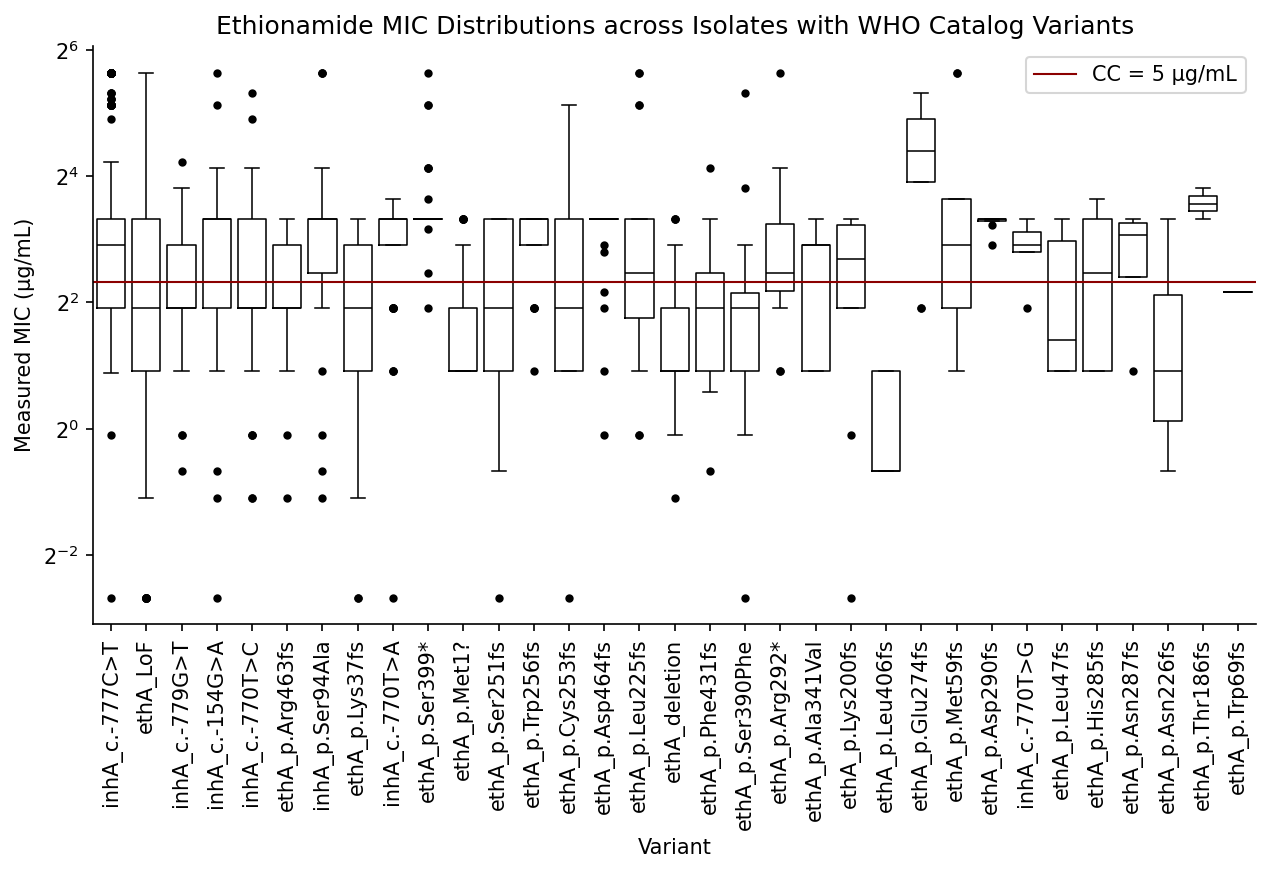

In [106]:
# keep the first 35 variants
keep_variants = df_ETO_MIC_by_resistance_variant.drop_duplicates(subset='Count').sort_values("Count", ascending=False).variant.values[:35]

fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_ETO_MIC_by_resistance_variant.query("variant in @keep_variants").sort_values("Count", ascending=False),
            x='variant',
            y='MIC',
            log_scale=2,
            whis=1,
            fliersize=3,
            fill=False,
            color='black',
            linewidth=0.75,
            flierprops={"markerfacecolor": "black"},
           )

plt.axhline(5, color='darkred', linewidth=1, label = "CC = 5 µg/mL")
plt.xticks(rotation=90)
plt.legend()
plt.ylabel('Measured MIC (µg/mL)')
plt.xlabel('Variant')
plt.title("Ethionamide MIC Distributions across Isolates with WHO Catalog Variants")

sns.despine()
plt.savefig("./MtbQuantCNN/results/Ethionamide/MIC_distributions_by_WHO_variant.svg", bbox_inches='tight')

# Loss Curves

Plot validation loss for the 5 CV replicates and the actual model on top. 

In [97]:
def plot_histories(path, patience_epochs=200, cv=True, saveName=None):

    if cv:
        combined_replicates = [pd.read_csv(fName)[['val_loss']] for fName in glob.glob(os.path.join(path, f"cross_validation/history*.csv"))]
    
    history = pd.read_csv(os.path.join(path, "history.csv"))

    if patience_epochs != 0:
        history = history.iloc[:-patience_epochs, :]
    
    fig, ax = plt.subplots(figsize=(10, 4))

    if cv:
        for i, single_rep in enumerate(combined_replicates):

            if patience_epochs !=  0:
                single_rep = single_rep.iloc[:-patience_epochs, :]
                
            print(f"Trained replicate {i} for {len(single_rep)} epochs")
            
            plt.plot(single_rep.index.values + 1, single_rep['val_loss'], color="lightgray")

    plt.plot(history.index + 1, history["val_loss"], color="red", linewidth=1.5)
    print(f"Trained full model for {len(history)} epochs")

    plt.xlabel("Epoch", fontsize=10)
    plt.ylabel("Validation Loss", fontsize=10)
    
    plot_title = "Validation Loss" + " for " + os.path.basename(path) + " Model"
    plt.title(plot_title, fontsize=12)
    sns.despine()
    
    if saveName is None:
        plt.show()
    else:
        if not os.path.isdir(os.path.dirname(saveName)):
            os.makedirs(os.path.dirname(saveName))
        plt.savefig(saveName)


BDQ
Trained replicate 0 for 682 epochs
Trained replicate 1 for 699 epochs
Trained replicate 2 for 619 epochs
Trained replicate 3 for 823 epochs
Trained replicate 4 for 1009 epochs
Trained full model for 462 epochs

EMB
Trained replicate 0 for 502 epochs
Trained replicate 1 for 390 epochs
Trained replicate 2 for 433 epochs
Trained replicate 3 for 420 epochs
Trained replicate 4 for 629 epochs
Trained full model for 477 epochs

ETO
Trained replicate 0 for 423 epochs
Trained replicate 1 for 504 epochs
Trained replicate 2 for 443 epochs
Trained replicate 3 for 412 epochs
Trained replicate 4 for 806 epochs
Trained full model for 593 epochs

INH
Trained replicate 0 for 574 epochs
Trained replicate 1 for 542 epochs
Trained replicate 2 for 559 epochs
Trained replicate 3 for 442 epochs
Trained replicate 4 for 768 epochs
Trained full model for 607 epochs

LFX
Trained replicate 0 for 575 epochs
Trained replicate 1 for 394 epochs
Trained replicate 2 for 657 epochs
Trained replicate 3 for 432 epoch

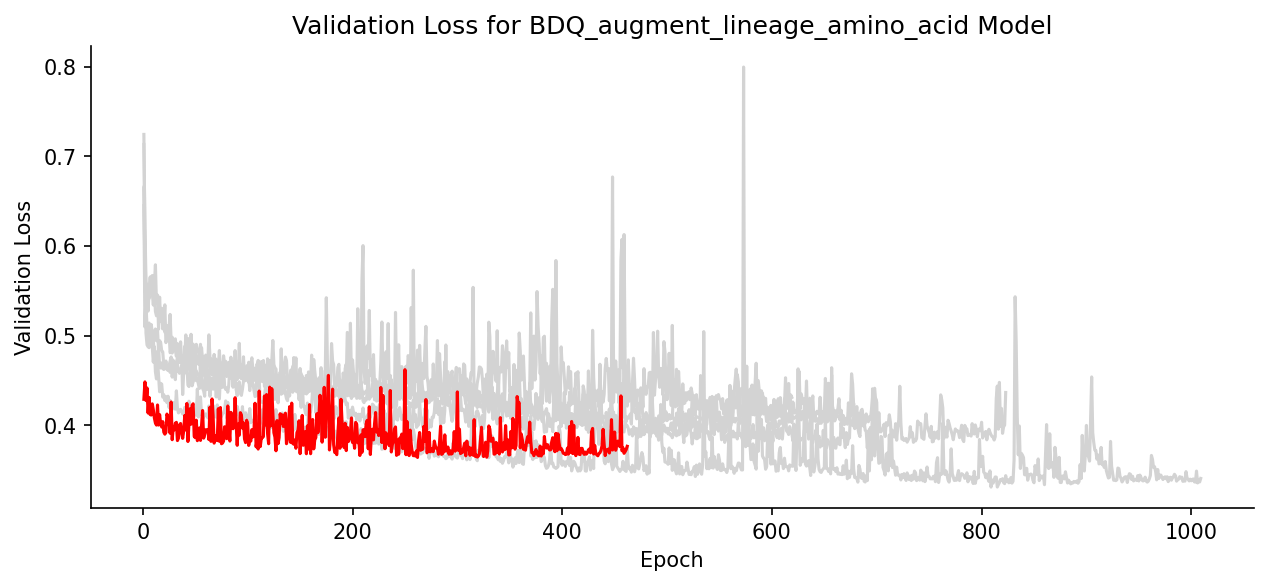

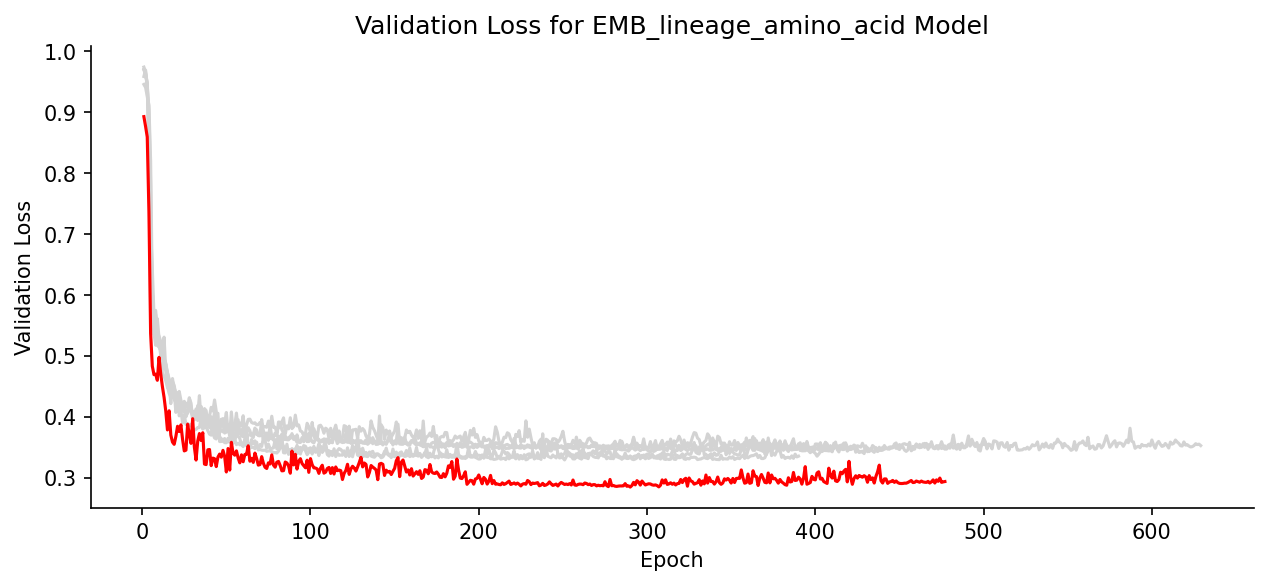

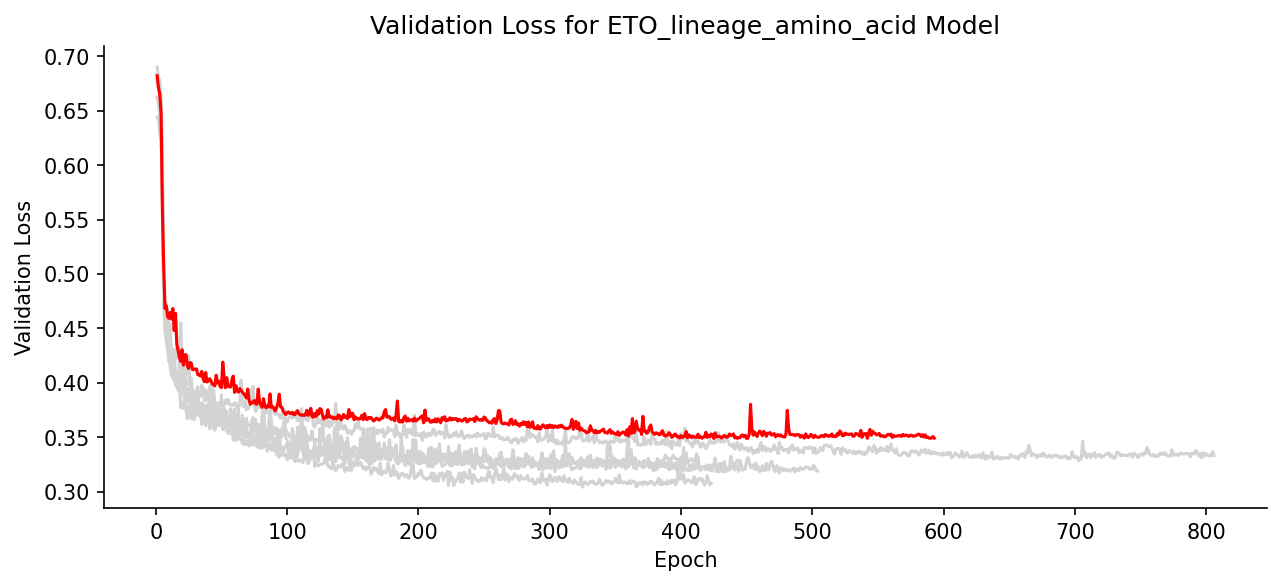

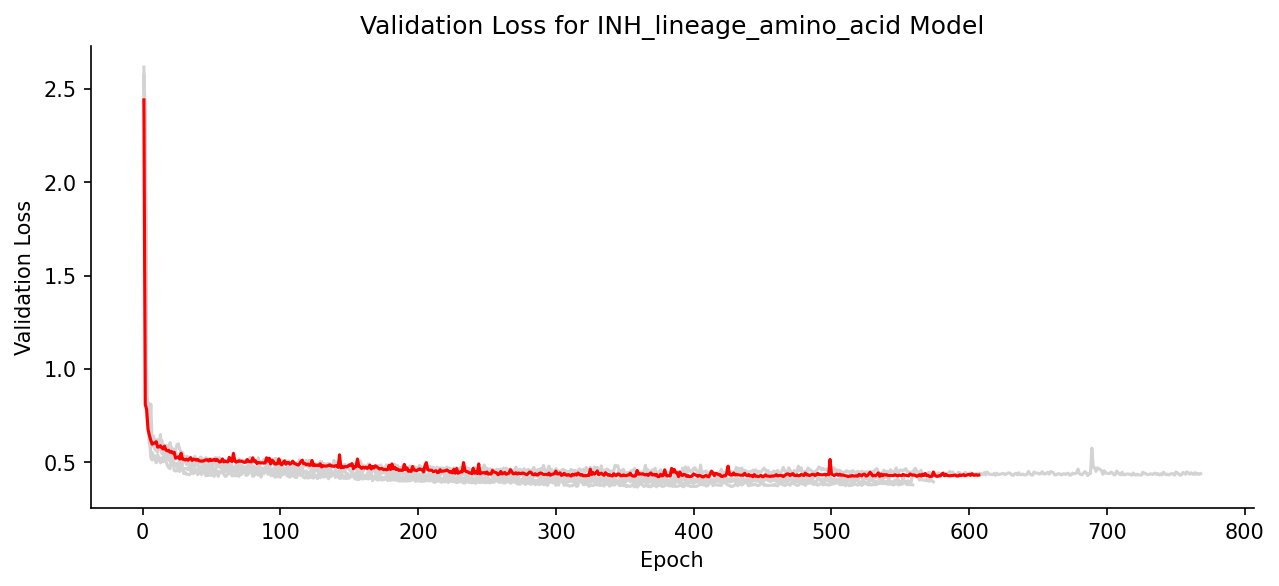

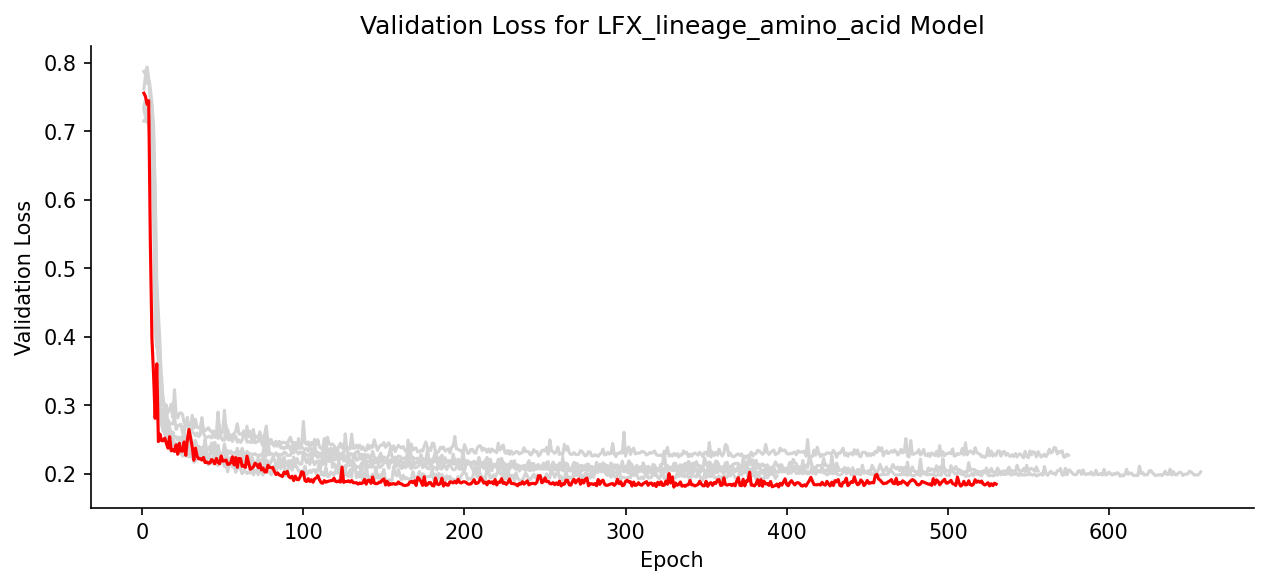

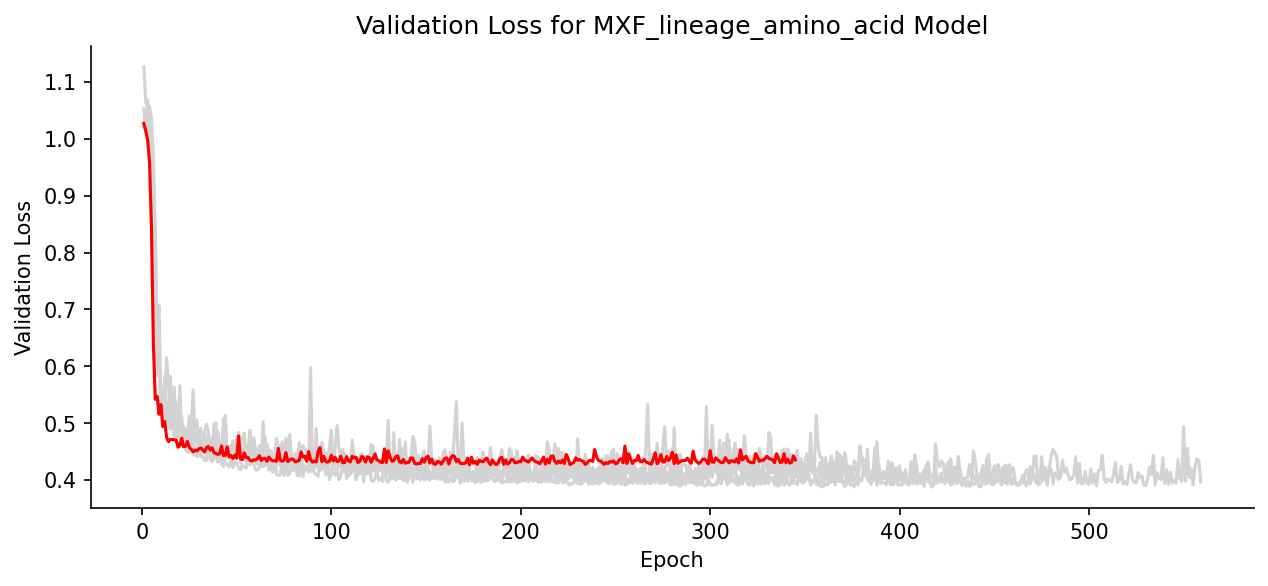

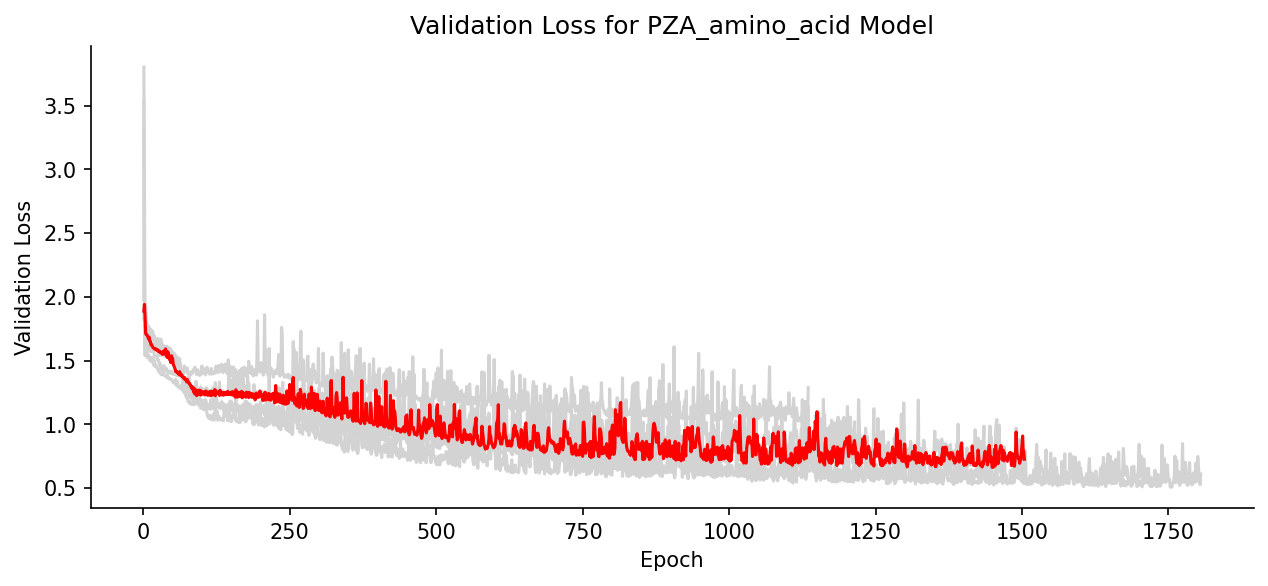

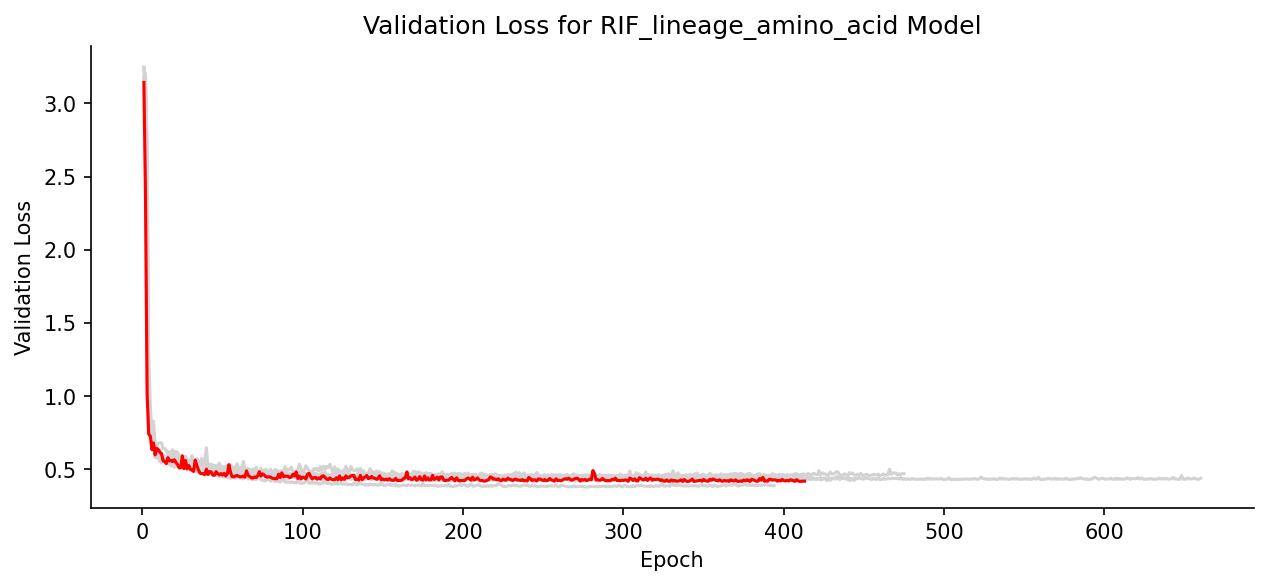

In [99]:
for drug in drugs_lst:
    
    print(f"\n{drug}")

    if drug == 'PZA':
        model_path = 'PZA_amino_acid'
    elif drug == 'BDQ':
        model_path = 'BDQ_augment_lineage_amino_acid'
    else:
        model_path = f'{drug}_lineage_amino_acid'
    
    plot_histories(os.path.join(results_dir, model_path), patience_epochs=0, cv=True, saveName=f"results/{abbr_drug_dict[drug]}/loss_curves.svg")

# After BDQ Augmentation, do the test predictions generally change?

## Want to make sure that there isn't a general shift to larger predicted MICS

In [23]:
df_BDQ = pd.read_csv(f"{data_dir}/BDQ_augment/data_for_model.csv")

df_test = pd.read_csv(f"{results_dir}/BDQ_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")
df_test_augmented = pd.read_csv(f"{results_dir}/BDQ_augment_lineage_amino_acid/test_predictions.csv").query("Span_CC==0")

df_test = df_test.merge(df_test_augmented[['Isolate', 'y_pred']].rename(columns={'y_pred': 'y_pred_augmented'}))
df_test['Resistant'] = (df_test['lower'] >= 0.25).astype(int)

df_test['y_pred_exp'] = np.exp2(df_test['y_pred'])
df_test['y_pred_augmented_exp'] = np.exp2(df_test['y_pred_augmented'])

df_test['diff'] = df_test['y_pred_augmented'] - df_test['y_pred']
df_test['diff_exp'] = df_test['y_pred_augmented_exp'] - df_test['y_pred_exp']

df_test['FC_exp'] = df_test['y_pred_augmented_exp'] / df_test['y_pred_exp']
df_test['log2_FC_exp'] = np.log2(df_test['FC_exp'])

df_test_susceptible = df_test.query("upper <= 0.25")
len(df_test), len(df_test_susceptible)

(1826, 1800)

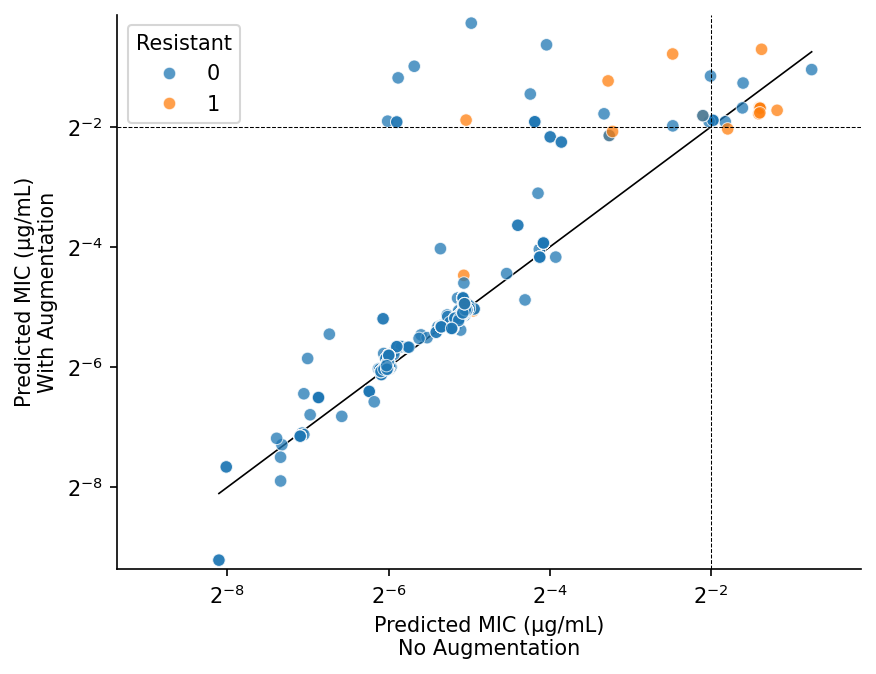

In [3]:
sns.scatterplot(data=df_test,
                x='y_pred_exp',
                y='y_pred_augmented_exp',
                alpha=0.75,
                hue='Resistant'
               )

plt.xscale('log', base=2)
plt.yscale('log', base=2)

plt.plot(np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         np.linspace(df_test['y_pred_exp'].min(), df_test['y_pred_exp'].max(), 10),
         color='black',
         zorder=0,
         linewidth=0.8,
        )

plt.axhline(y=0.25, linestyle='--', color='black', linewidth=0.5)
plt.axvline(x=0.25, linestyle='--', color='black', linewidth=0.5)

max_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.max()
min_val = df_test[['y_pred_exp', 'y_pred_augmented_exp']].values.min()

plt.xlim(min_val*0.9, max_val*1.1)
plt.ylim(min_val*0.9, max_val*1.1)

plt.xlabel('Predicted MIC (µg/mL)\nNo Augmentation')
plt.ylabel('Predicted MIC (µg/mL)\nWith Augmentation')

sns.despine()
plt.savefig("./results/Bedaquiline/test_predictions_augmentation_compare.svg", bbox_inches='tight')

In [10]:
# use non-parametric test rather than parametric because the augmentation should only affect isolates with resistance mutations
# so the shift in predicted MICs is expected to affect only certain isolates, so the difference between predictions isn't expected to be symmetric about 0 
st.wilcoxon(df_test['y_pred_exp'],
            df_test['y_pred_augmented_exp'],
            alternative='less'
           )

WilcoxonResult(statistic=868117.0, pvalue=0.9352075721697812)

In [11]:
st.wilcoxon(df_test.query("Resistant==1")['y_pred_exp'],
            df_test.query("Resistant==1")['y_pred_augmented_exp'],
            alternative='less'
           )

WilcoxonResult(statistic=158.0, pvalue=0.3354863077402115)

In [33]:
st.wilcoxon(df_test.query("lower >= 0.12")['y_pred_exp'],
            df_test.query("lower >= 0.12")['y_pred_augmented_exp'],
            alternative='less'
           )

WilcoxonResult(statistic=990.0, pvalue=0.0007955525027321129)

In [39]:
print(len(df_test.query("y_pred_augmented_exp >= 0.25")))

st.wilcoxon(df_test.query("y_pred_augmented_exp >= 0.25")['y_pred_exp'],
            df_test.query("y_pred_augmented_exp >= 0.25")['y_pred_augmented_exp'],
            alternative='less'
           )

37


WilcoxonResult(statistic=145.0, pvalue=0.0006739664459018968)